# Quick start guide

📄 Source: https://matplotlib.org/stable/users/explain/quick_start.html

Basic usage patterns and best practices to get started with Matplotlib.
This notebook follows the page heading by heading. The one idea to take away is in **Coding styles**: create `fig, ax = plt.subplots()` and call methods on `ax`.

**Skipped (as planned in the README):** *Using mathematical expressions in text*.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

print("matplotlib", mpl.__version__)

matplotlib 3.11.2


## A simple example

Matplotlib draws your data on **Figures** (windows, Jupyter widgets...). Each Figure holds one or more **Axes**: an area where points are placed using x-y coordinates.
The simplest way to get a Figure with one Axes is `plt.subplots()`. Then `Axes.plot` draws the data.

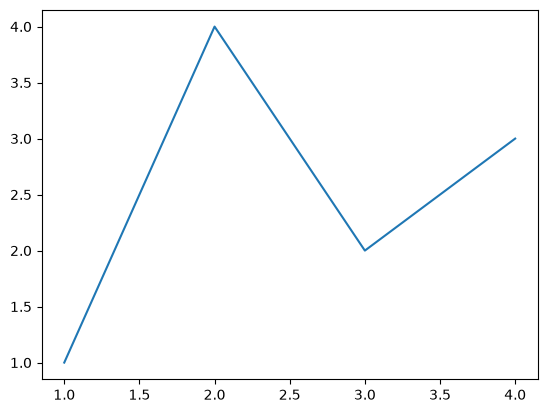

In [2]:
fig, ax = plt.subplots()             # Create a figure containing a single Axes.
ax.plot([1, 2, 3, 4], [1, 4, 2, 3])  # Plot some data on the Axes.
plt.show()                           # Show the figure (optional in Jupyter: figures in a cell are shown automatically).

## Parts of a Figure

The components of a Matplotlib Figure (study this image until you can draw it from memory):

![anatomy of a figure](https://matplotlib.org/stable/_images/anatomy.png)

### Figure
The **whole** figure. It keeps track of all child Axes, a group of "special" Artists (titles, figure legends, colorbars...) and even nested subfigures.

```python
fig = plt.figure()             # an empty figure with no Axes
fig, ax = plt.subplots()       # a figure with a single Axes
fig, axs = plt.subplots(2, 2)  # a figure with a 2x2 grid of Axes
# a figure with one Axes on the left, and two on the right:
fig, axs = plt.subplot_mosaic([['left', 'right_top'],
                               ['left', 'right_bottom']])
```

### Axes
An Artist attached to a Figure that contains the region for plotting data. It usually has two **Axis** objects (careful: **Axes** ≠ **Axis**) that give the ticks and tick labels.
Each Axes also has a title (`set_title`), an x-label (`set_xlabel`) and a y-label (`set_ylabel`).
**The Axes methods are the main interface** for adding data, setting scales and limits, and labelling.

### Axis
Sets the scale and limits and creates the ticks and tick labels. Tick *positions* come from a `Locator`, tick *label strings* from a `Formatter`.

### Artist
Basically **everything visible on the Figure is an Artist** (even the Figure, Axes and Axis objects): `Text`, `Line2D`, collections, `Patch`... When the figure is rendered, all Artists are drawn to the **canvas**. Most Artists belong to one Axes and cannot be shared or moved between Axes.

In [3]:
# A quick look at the tree from the image above, using the simple figure we made:
fig, ax = plt.subplots()
ax.plot([1, 2, 3, 4], [1, 4, 2, 3])

print(fig)              # the Figure
print(fig.axes)         # list of Axes inside the Figure
print(ax.xaxis)         # one of the two Axis objects inside the Axes
print(ax.lines)         # the Line2D Artist that ax.plot() created
plt.close(fig)          # don't draw this one again

Figure(640x480)
[<Axes: >]
XAxis(80.0,52.8)
<Axes.ArtistList of 1 lines>


## Types of inputs to plotting functions

Plotting functions expect `numpy.array` (or something `np.asarray` can convert). Array-like objects such as pandas objects *may* not work as intended, so the usual convention is to convert them to arrays first.

Most methods also accept a **string-indexable object** (a dict, a structured array, or a `pandas.DataFrame`): pass it with `data=` and then give column **names** as strings.

Text(0, 0.5, 'entry b')

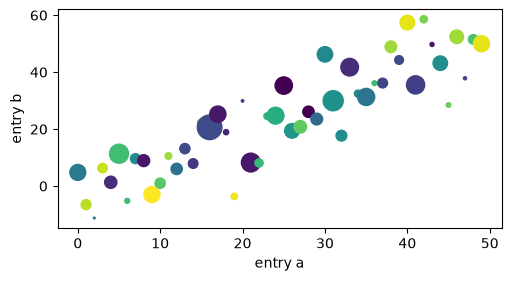

In [4]:
np.random.seed(19680801)  # seed the random number generator (same numbers as the docs).
data = {'a': np.arange(50),
        'c': np.random.randint(0, 50, 50),
        'd': np.random.randn(50)}
data['b'] = data['a'] + 10 * np.random.randn(50)
data['d'] = np.abs(data['d']) * 100

fig, ax = plt.subplots(figsize=(5, 2.7), layout='constrained')
# x='a', y='b', colour from 'c', marker size from 'd' -- all looked up inside `data`
ax.scatter('a', 'b', c='c', s='d', data=data)
ax.set_xlabel('entry a')
ax.set_ylabel('entry b')

## Coding styles

### The explicit and the implicit interfaces

There are two ways to use Matplotlib:

- **Explicit / object-oriented (OO) style:** create Figures and Axes yourself and call methods on them.
- **Implicit / pyplot style:** let `pyplot` create and manage Figures and Axes, and call `plt.*` functions.

The OO style:

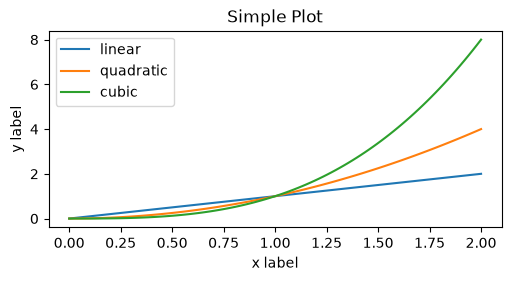

In [5]:
x = np.linspace(0, 2, 100)  # Sample data.

# Note that even in the OO-style, we use `pyplot` to create the Figure.
fig, ax = plt.subplots(figsize=(5, 2.7), layout='constrained')
ax.plot(x, x, label='linear')        # Plot some data on the Axes.
ax.plot(x, x**2, label='quadratic')  # Plot more data on the Axes...
ax.plot(x, x**3, label='cubic')      # ... and some more.
ax.set_xlabel('x label')             # Add an x-label to the Axes.
ax.set_ylabel('y label')             # Add a y-label to the Axes.
ax.set_title("Simple Plot")          # Add a title to the Axes.
ax.legend()                          # Add a legend.

The same plot in pyplot style:

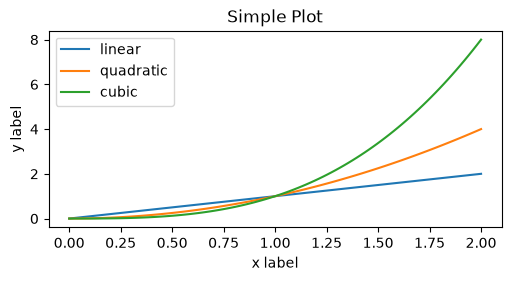

In [6]:
x = np.linspace(0, 2, 100)  # Sample data.

plt.figure(figsize=(5, 2.7), layout='constrained')
plt.plot(x, x, label='linear')        # Plot some data on the (implicit) Axes.
plt.plot(x, x**2, label='quadratic')  # etc.
plt.plot(x, x**3, label='cubic')
plt.xlabel('x label')
plt.ylabel('y label')
plt.title("Simple Plot")
plt.legend()

The docs suggest the **OO style**, especially for complicated plots and for functions/scripts you want to reuse. Pyplot is fine for quick interactive work.
(`from pylab import *` in old examples is strongly deprecated.)

### Making a helper function

If you make the same plot again and again with different data, wrap it in a function with this signature: **take an `ax`, draw on it, return the artists**. (This is the seed of `plotting_utils.py`.)

In [7]:
def my_plotter(ax, data1, data2, param_dict):
    """
    A helper function to make a graph.
    """
    out = ax.plot(data1, data2, **param_dict)  # draw on the Axes we were given
    return out                                 # return the artists, so the caller can change them later

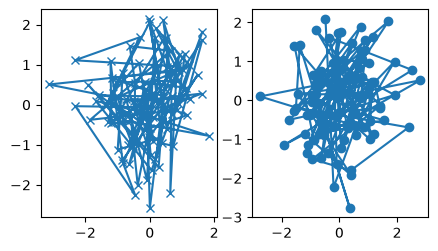

In [8]:
# Use the helper twice to fill two subplots
data1, data2, data3, data4 = np.random.randn(4, 100)  # make 4 random data sets
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5, 2.7))
my_plotter(ax1, data1, data2, {'marker': 'x'})
my_plotter(ax2, data3, data4, {'marker': 'o'})

## Styling Artists

Most plotting methods take styling options when you call them, or you can change them afterwards with a **setter** on the Artist.
Below: colour, linewidth and linestyle are set in the call, and the second line's linestyle is changed later with `set_linestyle`.

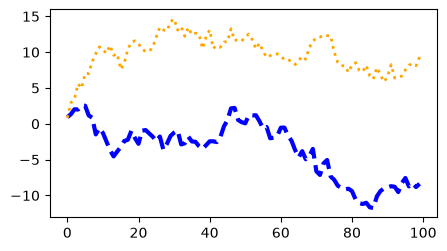

In [9]:
fig, ax = plt.subplots(figsize=(5, 2.7))
x = np.arange(len(data1))
ax.plot(x, np.cumsum(data1), color='blue', linewidth=3, linestyle='--')  # style set in the call
l, = ax.plot(x, np.cumsum(data2), color='orange', linewidth=2)         # note the comma: plot returns a list
l.set_linestyle(':')                                                    # style changed afterwards via a setter

### Colors

Matplotlib accepts many colour formats (names, hex, `'C0'`...`'C9'` for the default cycle, RGB tuples). Some Artists take several colours, e.g. a scatter marker can have a different edge and face colour.

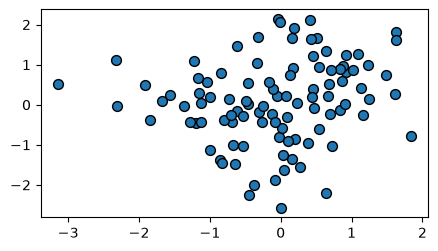

In [10]:
fig, ax = plt.subplots(figsize=(5, 2.7))
ax.scatter(data1, data2, s=50, facecolor='C0', edgecolor='k')  # 'C0' = first colour of the default cycle, 'k' = black

### Linewidths, linestyles, and markersizes

- Line widths are in typographic points (1 pt = 1/72 inch).
- Marker size depends on the method: `plot` uses `markersize` in points (≈ diameter); `scatter` uses `s` ≈ marker **area**.
- Marker shapes are string codes (`'o'`, `'d'`, `'v'`, `'s'`...).

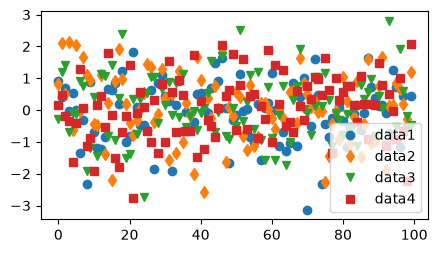

In [11]:
fig, ax = plt.subplots(figsize=(5, 2.7))
ax.plot(data1, 'o', label='data1')  # circles
ax.plot(data2, 'd', label='data2')  # diamonds
ax.plot(data3, 'v', label='data3')  # triangles down
ax.plot(data4, 's', label='data4')  # squares
ax.legend()

## Labelling plots

### Axes labels and text

`set_xlabel`, `set_ylabel` and `set_title` put text in fixed places. `ax.text` puts text anywhere, in data coordinates.

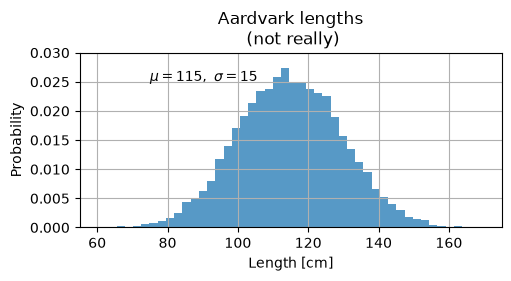

In [12]:
mu, sigma = 115, 15
x = mu + sigma * np.random.randn(10000)
fig, ax = plt.subplots(figsize=(5, 2.7), layout='constrained')
# the histogram of the data: returns counts, bin edges, and the bar patches
n, bins, patches = ax.hist(x, 50, density=True, facecolor='C0', alpha=0.75)

ax.set_xlabel('Length [cm]')
ax.set_ylabel('Probability')
ax.set_title('Aardvark lengths\n (not really)')
ax.text(75, .025, r'$\mu=115,\ \sigma=15$')  # text placed at data point (75, 0.025)
ax.axis([55, 175, 0, 0.03])                  # [xmin, xmax, ymin, ymax]
ax.grid(True)

All text functions return a `matplotlib.text.Text` instance, so you can style it with keyword arguments, e.g. `t = ax.set_xlabel('my data', fontsize=14, color='red')`.

### Annotations

Annotate a point with an arrow pointing to `xy` from text placed at `xytext`:

(-2.0, 2.0)

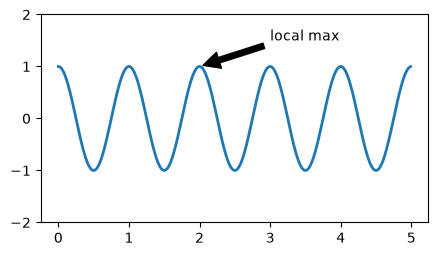

In [13]:
fig, ax = plt.subplots(figsize=(5, 2.7))

t = np.arange(0.0, 5.0, 0.01)
s = np.cos(2 * np.pi * t)
line, = ax.plot(t, s, lw=2)

ax.annotate('local max',
            xy=(2, 1),         # the point being annotated (arrow tip), in data coordinates
            xytext=(3, 1.5),   # where the text goes, also in data coordinates
            arrowprops=dict(facecolor='black', shrink=0.05))

ax.set_ylim(-2, 2)

### Legends

Identify lines or markers with `Axes.legend` (it uses each artist's `label=`):

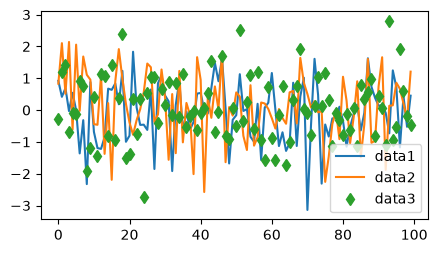

In [14]:
fig, ax = plt.subplots(figsize=(5, 2.7))
ax.plot(np.arange(len(data1)), data1, label='data1')
ax.plot(np.arange(len(data2)), data2, label='data2')
ax.plot(np.arange(len(data3)), data3, 'd', label='data3')
ax.legend()

## Axis scales and ticks

Each Axes has two (or three) Axis objects. They control the **scale**, the tick **locators** and the tick **formatters**.

### Scales

Besides linear, there are non-linear scales such as log. Shortcuts exist: `loglog`, `semilogx`, `semilogy`. Here the scale is set by hand:

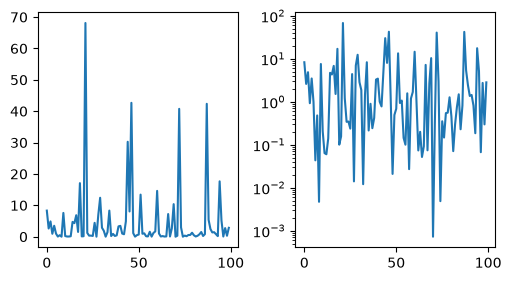

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(5, 2.7), layout='constrained')
xdata = np.arange(len(data1))  # make an ordinal for this
data = 10**data1               # values spread over several orders of magnitude
axs[0].plot(xdata, data)       # linear scale: hard to read

axs[1].set_yscale('log')       # log scale: the same data becomes readable
axs[1].plot(xdata, data)

The scale maps data values to spacing along the Axis. It is part of the *transform* that goes from data coordinates to screen coordinates.

### Tick locators and formatters

Each Axis has a tick *locator* (where ticks go) and *formatter* (what the labels say). The simple interface is `set_xticks` / `set_yticks`:

Text(0.5, 1.0, 'Manual ticks')

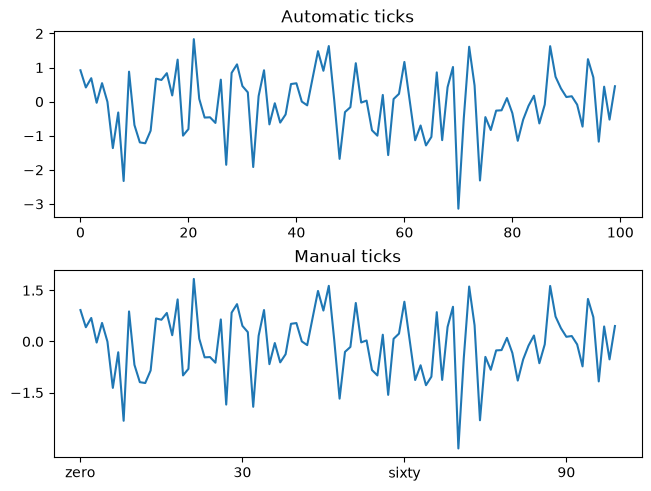

In [16]:
fig, axs = plt.subplots(2, 1, layout='constrained')
axs[0].plot(xdata, data1)
axs[0].set_title('Automatic ticks')

axs[1].plot(xdata, data1)
axs[1].set_xticks(np.arange(0, 100, 30), ['zero', '30', 'sixty', '90'])  # positions + custom labels
axs[1].set_yticks([-1.5, 0, 1.5])  # note that we don't need to specify labels
axs[1].set_title('Manual ticks')

### Plotting dates and strings

Matplotlib can plot arrays of dates and arrays of strings, with special locators/formatters. For dates, `ConciseDateFormatter` gives short, readable labels:

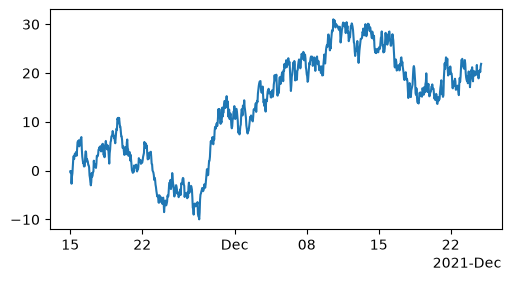

In [17]:
from matplotlib.dates import ConciseDateFormatter

fig, ax = plt.subplots(figsize=(5, 2.7), layout='constrained')
dates = np.arange(np.datetime64('2021-11-15'), np.datetime64('2021-12-25'),
                  np.timedelta64(1, 'h'))                # one value per hour
data = np.cumsum(np.random.randn(len(dates)))            # a random walk
ax.plot(dates, data)
# keep the automatic tick positions, but use the concise date labels
ax.xaxis.set_major_formatter(ConciseDateFormatter(ax.xaxis.get_major_locator()))

For strings you get **categorical** plotting:

<BarContainer object of 4 artists>

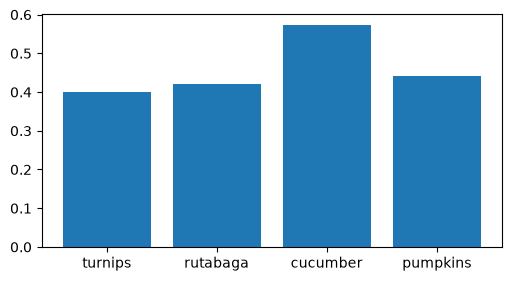

In [18]:
fig, ax = plt.subplots(figsize=(5, 2.7), layout='constrained')
categories = ['turnips', 'rutabaga', 'cucumber', 'pumpkins']

ax.bar(categories, np.random.rand(len(categories)))  # each string becomes one category on the x-axis

⚠️ Caveat: if a file parser gives you numbers or dates **as strings**, Matplotlib treats every string as a category. 1000 strings = 1000 ticks. Convert types first (that's the pandas cleaning step).

### Additional Axis objects

- `twinx()` adds a new Axes with an invisible x-axis and a y-axis on the right (`twiny()` for the top). Use with care: two y-scales on one chart are easy to misread.
- `secondary_xaxis` / `secondary_yaxis` show the **same** data in a different unit (e.g. radians and degrees).

Text(0.5, 0, 'Angle [°]')

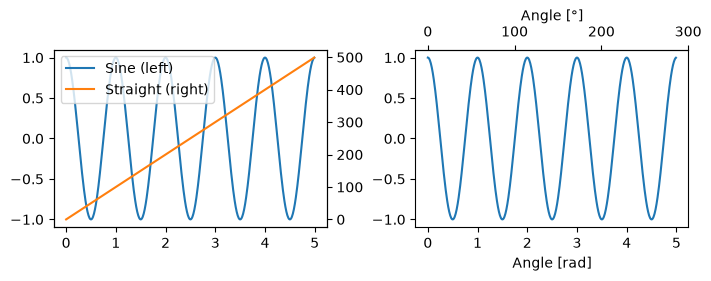

In [19]:
fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(7, 2.7), layout='constrained')

# Left: twinx -> two different data series, two different y scales
l1, = ax1.plot(t, s)
ax2 = ax1.twinx()                              # new Axes sharing ax1's x-axis, y-axis on the right
l2, = ax2.plot(t, range(len(t)), 'C1')
ax2.legend([l1, l2], ['Sine (left)', 'Straight (right)'])

# Right: secondary axis -> same data, a second unit on top
ax3.plot(t, s)
ax3.set_xlabel('Angle [rad]')
ax4 = ax3.secondary_xaxis('top', (np.rad2deg, np.deg2rad))  # (forward, inverse) conversion functions
ax4.set_xlabel('Angle [°]')

## Color mapped data

Often a third dimension is shown with colour from a **colormap**. Several plot types do this:

Text(0.5, 1.0, 'scatter()')

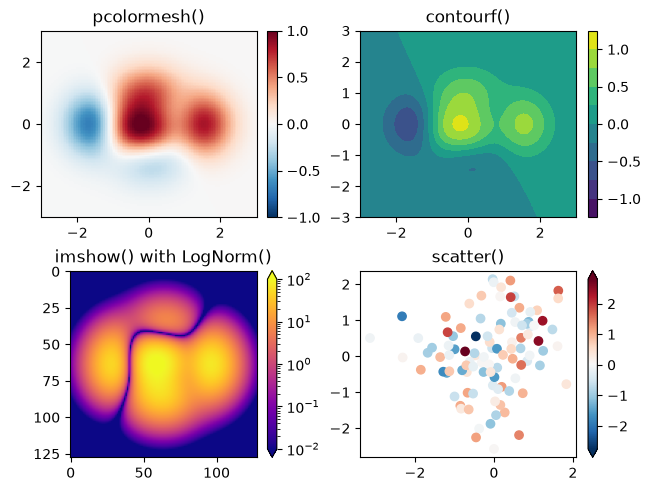

In [20]:
from matplotlib.colors import LogNorm

X, Y = np.meshgrid(np.linspace(-3, 3, 128), np.linspace(-3, 3, 128))
Z = (1 - X/2 + X**5 + Y**3) * np.exp(-X**2 - Y**2)

fig, axs = plt.subplots(2, 2, layout='constrained')

# pcolormesh: colour each grid cell; vmin/vmax fix the colour range
pc = axs[0, 0].pcolormesh(X, Y, Z, vmin=-1, vmax=1, cmap='RdBu_r')
fig.colorbar(pc, ax=axs[0, 0])
axs[0, 0].set_title('pcolormesh()')

# contourf: filled contour bands at the given levels
co = axs[0, 1].contourf(X, Y, Z, levels=np.linspace(-1.25, 1.25, 11))
fig.colorbar(co, ax=axs[0, 1])
axs[0, 1].set_title('contourf()')

# imshow with a LogNorm: non-linear mapping of values to colours
pc = axs[1, 0].imshow(Z**2 * 100, cmap='plasma', norm=LogNorm(vmin=0.01, vmax=100))
fig.colorbar(pc, ax=axs[1, 0], extend='both')   # extend='both' draws arrows for out-of-range values
axs[1, 0].set_title('imshow() with LogNorm()')

# scatter: colour each point by a third variable
pc = axs[1, 1].scatter(data1, data2, c=data3, cmap='RdBu_r')
fig.colorbar(pc, ax=axs[1, 1], extend='both')
axs[1, 1].set_title('scatter()')

### Colormaps
All of these are `ScalarMappable` artists: they map values between `vmin` and `vmax` onto the colormap given by `cmap`. (How to *choose* a colormap is notebook 07.)

### Normalizations
For a non-linear mapping, pass a `norm=` instead of `vmin`/`vmax` (like `LogNorm` above).

### Colorbars
`fig.colorbar(mappable, ax=...)` adds a key from colour back to data. Colorbars are figure-level Artists and usually **steal space** from their parent Axes. `extend` adds arrows at the ends; `shrink` and `aspect` control the size.

## Working with multiple Figures and Axes

Call `plt.figure()` / `plt.subplots()` again for more Figures; keep the references to add Artists to each.
For Axes that span rows or columns, use `subplot_mosaic` (more in notebook 05):

Text(0.5, 1.0, 'right')

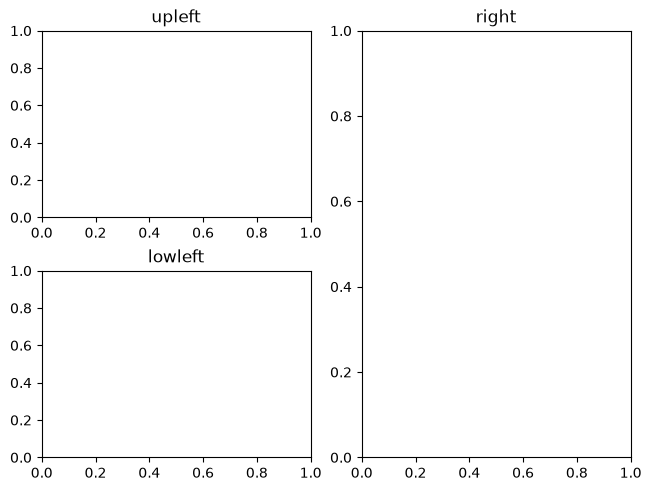

In [21]:
fig, axd = plt.subplot_mosaic([['upleft', 'right'],
                               ['lowleft', 'right']],   # repeating 'right' makes it span both rows
                              layout='constrained')
# axd is a dict: name -> Axes
axd['upleft'].set_title('upleft')
axd['lowleft'].set_title('lowleft')
axd['right'].set_title('right')

## Key takeaways

- **Figure → Axes → Axis → Artists.** Everything you see is an Artist.
- Start every chart with `fig, ax = plt.subplots(layout="constrained")` and use `ax.` methods (OO style).
- Helper functions should take `ax`, draw on it, and return the artists.
- Use `data=` with a DataFrame and column names; watch out for numbers stored as strings.
- Colour-mapped plots need a colormap, a norm (or `vmin`/`vmax`) and a colorbar.